In [6]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [7]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeNdtExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Covertype (on prend un sous-échantillon pour la rapidité)
data = fetch_covtype()
X = data.data[:2000]
y = data.target[:2000]

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeNdtExplainer(
    X_train,
    feature_names=[f'feature_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=X_train.shape[1],
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Explication locale (feature, poids):
[('feature_0', -1.075698287080419), ('feature_3', 0.4500785092398979), ('feature_5', 0.393344425307605), ('feature_8', 0.3272679116438884), ('feature_25', 0.14078875968992222), ('feature_36', -0.08766306681823932), ('feature_48', 0.08325000000000002), ('feature_4', 0.04833544080974339), ('feature_44', -0.04544696969696971), ('feature_6', -0.04022333402104389), ('feature_9', 0.034130939932613125), ('feature_15', 0.031619241192411995), ('feature_7', 0.029707661290322596), ('feature_1', 0.0), ('feature_43', 0.0), ('feature_37', 0.0), ('feature_33', 0.0), ('feature_42', 0.0), ('feature_10', 0.0), ('feature_52', 0.0), ('feature_31', 0.0), ('feature_35', 0.0), ('feature_46', 0.0), ('feature_14', 0.0), ('feature_29', 0.0), ('feature_22', 0.0), ('feature_51', 0.0), ('feature_21', 0.0), ('feature_41', 0.0), ('feature_53', 0.0), ('feature_30', 0.0), ('feature_45', 0.0), ('feature_1

In [8]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=X_train.shape[1]
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('Elevation', -0.07351950147111468), ('Horizontal_Distance_To_Hydrology', 0.039054242175034275), ('Hillshade_3pm', 0.021179200571949674), ('Aspect', 0.01529717987697495), ('Hillshade_Noon', 0.014394215976341032), ('Vertical_Distance_To_Hydrology', 0.013501109599630225), ('Soil_Type_11', 0.009781579390724866), ('Hillshade_9am', -0.007394295570656419), ('Soil_Type_22', -0.007058653684702373), ('Horizontal_Distance_To_Roadways', 0.0036086585050257914), ('Soil_Type_6', -0.002988111988505368), ('Soil_Type_3', -0.002932497971599701), ('Soil_Type_29', -0.002925139871673593), ('Soil_Type_1', 0.002734782078335478), ('Soil_Type_31', -0.0022804686625517326), ('Slope', -0.002133396765727276), ('Soil_Type_4', -0.0020791800357195358), ('Wilderness_Area_1', -0.001998523664217029), ('Soil_Type_18', 0.0018306591039349196), ('Soil_Type_27', 0.0017486934670223847), ('Soil_Type_24', -0.0017171121300112325), ('Soil_Type_35', -0.0016835015078

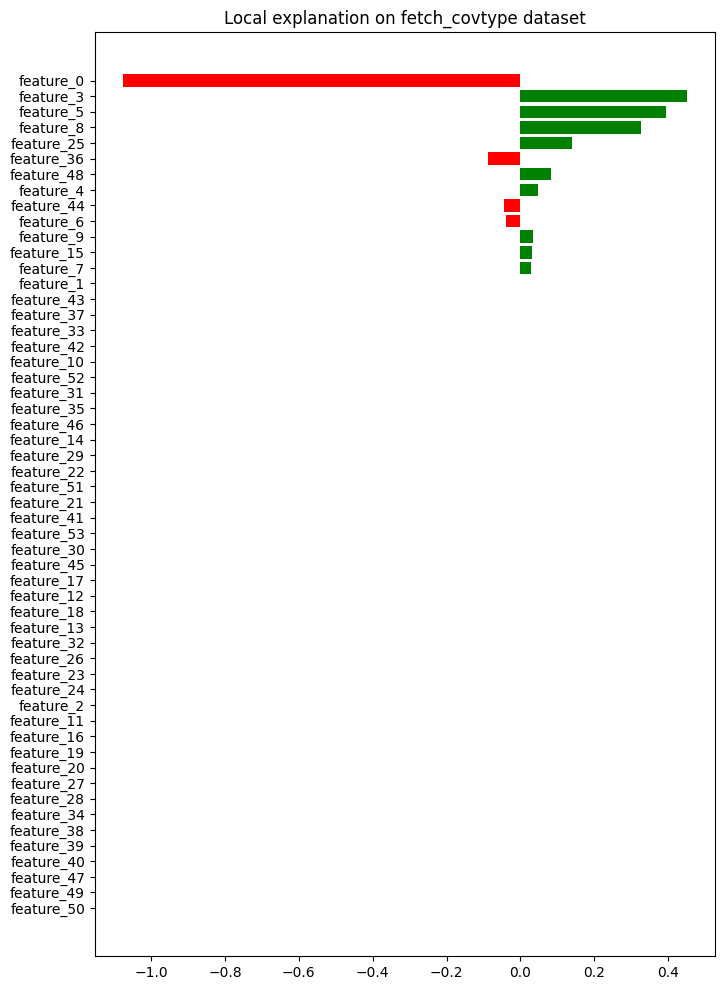

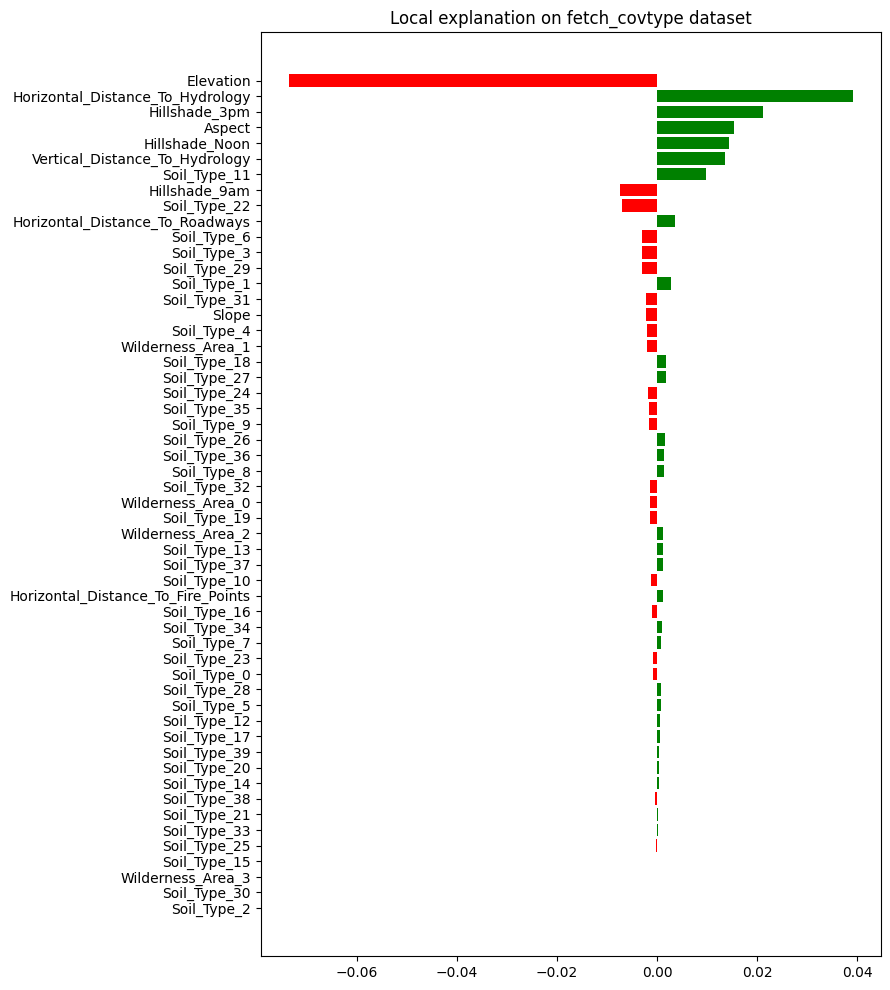

In [9]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 12)
fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 12)
fig.axes[0].set_title("Local explanation on fetch_covtype dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.set_size_inches(8, 12)
fig_ridge.axes[0].set_title("Local explanation on fetch_covtype dataset")
plt.show()